In [119]:

import pandas as pd
import numpy as np
from pandas_datareader.data import DataReader
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
import sys
import os
sys.path.append(os.path.abspath(".."))

# Crypto markets trade every day: one single annualisation convention is used everywhere
DAYS_PER_YEAR = 365


---
# Moving-Average-Price-Option-Inspired Residual Trading Strategy

## Inspiration

This strategy is inspired by the payoff structure of **average price options** (also called Asian options).

Unlike standard European options, their payoff depends on the **average price** of the underlying asset over a given period, rather than only on its terminal price.

This suggests that moving-average returns can be interpreted as a **synthetic underlying asset**, theoretically replicable through synthetic forward positions.

The interacting-agent model proposed by **<span style="color: #2e6f40;">Taisei Kaizoji</span>** (2000, 2006 — see references) showed good predictive ability on smoothed returns in my previous notebook. The strategy uses this property of the model to generate signals.

---
## Presentation of the strategy

The strategy is applied to residuals obtained from a **Principal Component Analysis (PCA)** of a portfolio of 30 cryptocurrencies.

PCA is used to extract the dominant common components driving the cross-section of assets. The residuals then represent the idiosyncratic component of the returns.

We then use the agent-based model (ABM) to predict the direction of the next residual and generate a signal.

This allows the strategy to exploit temporary imbalances in the residual component.

---

## Procedure

The procedure of this **short-horizon residual trading strategy** is:

1. compute PCA residuals and auxiliary series on a walk-forward basis;
2. use the ABM to forecast the next residuals;
3. exploit the anticorrelation between actual and forecasted residuals to generate signals;
4. compute the premium of the synthetic asset as transaction costs.

---

#### References
* Kaizoji, T. (2000). Speculative bubbles and crashes in stock markets: an interacting-agent model of speculative activity. *Physica A: Statistical Mechanics and its Applications*, 287(3–4), 493–506. [ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S0378437100003885).
* Kaizoji, T. (2006). An interacting-agent model of financial markets from the viewpoint of nonextensive statistical mechanics. *Physica A: Statistical Mechanics and its Applications*, 370(1), 109–113. [https://doi.org/10.1016/j.physa.2006.04.041](https://doi.org/10.1016/j.physa.2006.04.041).


In [120]:

# ============================================================
# Step 1 - Data cleaning and preprocessing
# ============================================================

# importing the crypto OHLC data
crypto_ohlc_df = pd.read_pickle('../data/crypto_ohlc.pkl')

# removing the non-relevant crypto-assets (stablecoins, leveraged UP/DOWN tokens, fiat pairs)
crypto_ohlc_df = crypto_ohlc_df.drop(columns=['USDC'], level=0)
coins = crypto_ohlc_df.columns.get_level_values(0)
cols_removed = coins.str.endswith(("UP", "DOWN", "USD"))
crypto_ohlc_df = crypto_ohlc_df.loc[:, ~cols_removed]

# rearranging the dataset (future_stack=False drops the all-NaN rows of each coin)
crypto_ohlc_df = crypto_ohlc_df.stack(level=0, future_stack=False).reset_index().rename(columns={"level_1": "crypto"})
crypto_ohlc_df = crypto_ohlc_df.set_index(["crypto", "date"]).sort_index()

# keeping only the cryptos with at least 95% of the BTC data points
counts = crypto_ohlc_df.groupby('crypto').size()
valid_crypto = counts[counts >= 0.95 * (crypto_ohlc_df.loc['BTC'].shape[0])]
crypto_ohlc_df = crypto_ohlc_df.loc[valid_crypto.index]


In [121]:
# ============================================================
# Step 2 - Defining the important features
# ============================================================

crypto_df = crypto_ohlc_df.replace([np.inf, -np.inf], np.nan)

# daily close prices on a regular calendar: a missing day stays NaN instead of
# being silently merged into a multi-day return
price = crypto_df['close'].unstack('crypto').asfreq('D')

# raw daily returns (the first return of each coin is NaN, not 0)
raw_returns = price.pct_change(fill_method=None)

# 10-day moving average of the returns (kept under the name `returns` for the rest of the notebook)
returns = raw_returns.dropna()
returns = returns.rolling(10).mean().dropna()


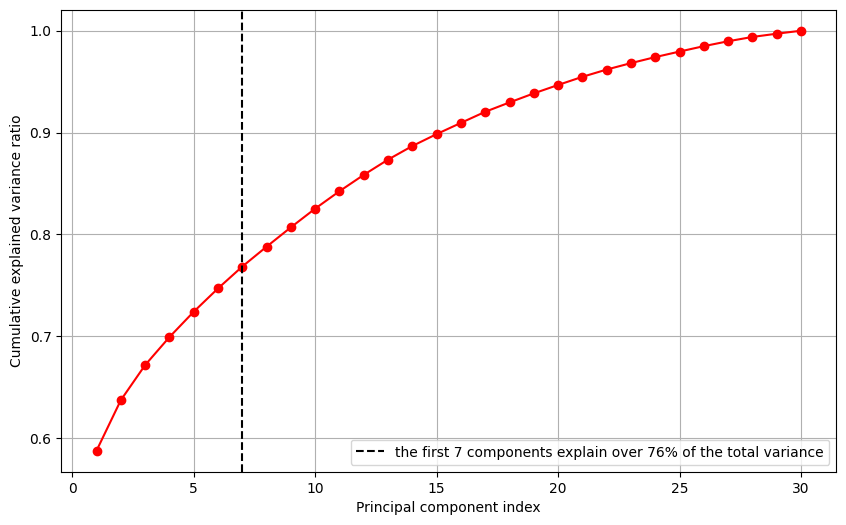

In [122]:
# ============================================================
# Step 3 - Analysing the explained variance via PCA
# (exploratory only: fitted on the full sample)
# ============================================================

number_of_components = 7  # number of principal components removed to compute the residuals

scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)
pca = PCA()
pca_components = pca.fit_transform(returns_scaled)
df_PCA = pd.DataFrame(data=pca_components, index=returns.index, columns=[f'PCA {i+1}' for i in range(len(returns.columns))])

plt.figure(figsize=(10, 6))
X = np.arange(1, len(pca.explained_variance_ratio_) + 1, 1)
Y = pca.explained_variance_ratio_.cumsum()
plt.plot(X, Y, 'ro-')
plt.xlabel('Principal component index')
plt.ylabel('Cumulative explained variance ratio')
plt.grid()
plt.axvline(
    x=number_of_components, linestyle='--', color="black",
    label=f"the first {number_of_components} components explain over {np.floor(Y[number_of_components-1]*100):.0f}% of the total variance",
)
plt.legend()
plt.show()


In [123]:
# =====================================================================================================
# Step 4 - Rolling explained variance of the principal components
# =====================================================================================================

window = 252  # length of the rolling estimation window (in days)
rolling_pca = []

# for each date t, the PCA is fitted on [t - window, t - 1]
for i in range(window, len(returns.index)):
    returns_sample = returns.iloc[i-window:i, :]
    returns_sample_scaled = StandardScaler().fit_transform(returns_sample)
    pca_window = PCA()
    pca_window.fit(returns_sample_scaled)
    rolling_pca.append(pca_window.explained_variance_ratio_)

rolling_pca_df = pd.DataFrame(rolling_pca, index=returns.index[window:], columns=[f'PCA{i+1}' for i in range(len(returns.columns))])


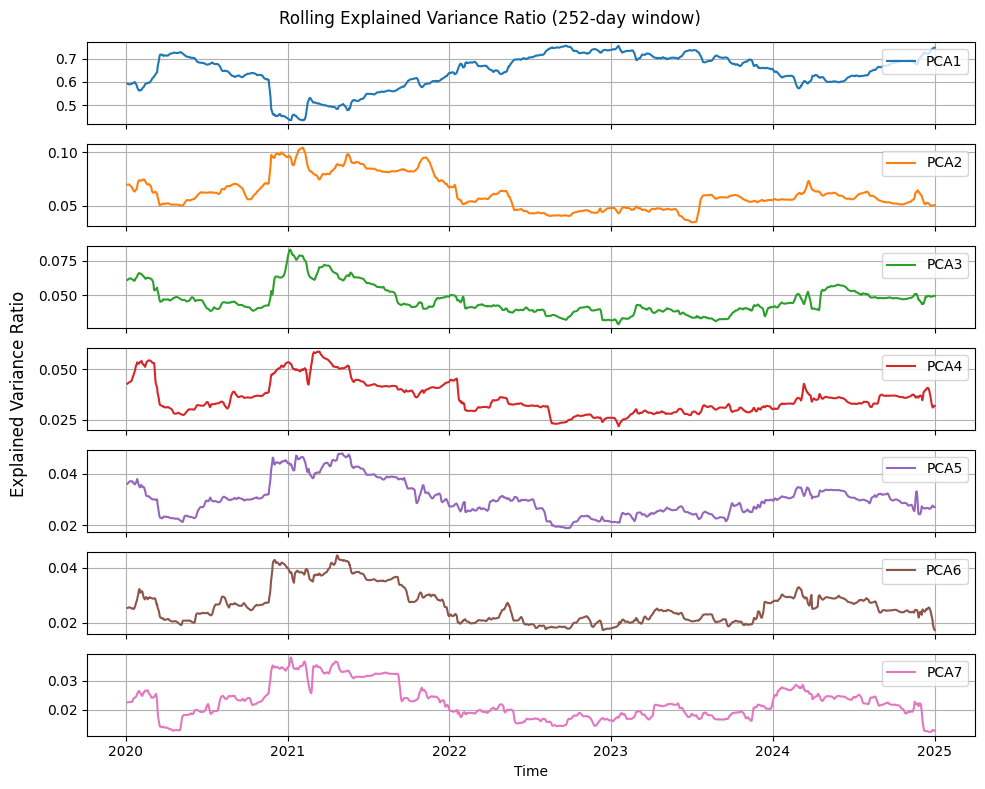

In [124]:

# selecting the explained variance ratios of the first components
cols = rolling_pca_df.columns[:number_of_components]

# plotting
fig, axes = plt.subplots(len(cols), 1, sharex=True, figsize=(10, 8))
colors = plt.cm.tab10.colors

for i, col in enumerate(cols):
    axes[i].plot(rolling_pca_df.index, rolling_pca_df[col], color=colors[i % len(colors)], label=col)
    axes[i].legend(loc="upper right")
    axes[i].grid(True)

axes[-1].set_xlabel('Time')
fig.suptitle(f'Rolling Explained Variance Ratio ({window}-day window)')
fig.supylabel('Explained Variance Ratio')
plt.tight_layout()
plt.show()


In [125]:
# =====================================================================================================
# Step 5 - Out-of-sample PCA residuals on a rolling window
# =====================================================================================================

# DataFrame containing the residuals of all coins computed on a rolling basis.
# The first `window` dates have no out-of-sample residual and are left as NaN
# (fitting and evaluating the PCA on the same data would introduce look-ahead bias).
residuals_df = pd.DataFrame(np.nan, index=returns.index, columns=returns.columns, dtype=float)

# progressive computation of the residuals with a rolling window to avoid look-ahead bias:
# the scaler and the PCA are fitted on [t - window, t - 1] and applied to date t
for i in range(window, len(returns.index)):
    returns_sample = returns.iloc[i-window:i]
    scaler = StandardScaler().fit(returns_sample)
    X_train = scaler.transform(returns_sample)            # (window, n_coins)
    X_test = scaler.transform(returns.iloc[[i]])          # (1, n_coins)

    pca_window = PCA(n_components=number_of_components)
    pca_window.fit(X_train)
    X_test_hat = pca_window.inverse_transform(pca_window.transform(X_test))   # (1, n_coins)

    # residual of date t, back to return units: r_t - (mu + sigma * x_hat) = sigma * (x - x_hat)
    residuals_df.iloc[i, :] = ((X_test - X_test_hat) * scaler.scale_).ravel()

residuals_df = residuals_df.iloc[window:]


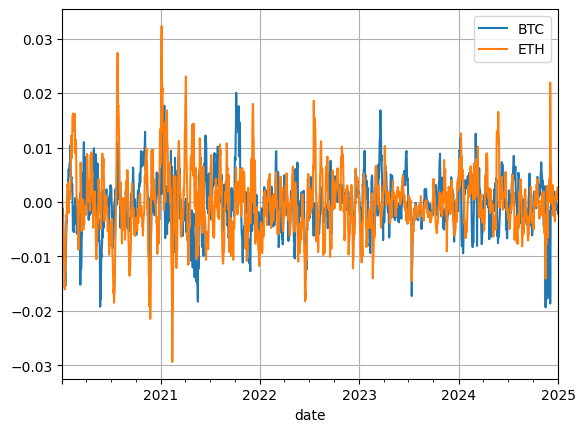

In [126]:
# plotting for reference: the residuals oscillate around zero (visual check only, no stationarity test)

residuals_df['BTC'].plot(label='BTC')
residuals_df['ETH'].plot(label='ETH')
plt.legend()
plt.grid()
plt.show()


In [127]:
# Computing the auxiliary series as the cumulative sum of the residuals
aux_series_df = residuals_df.cumsum()


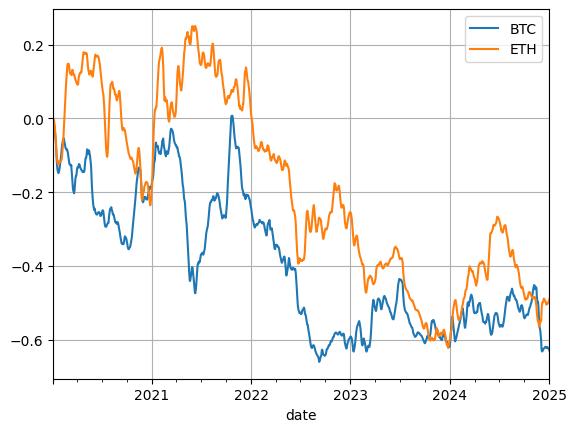

In [128]:
# Plotting for reference
aux_series_df['BTC'].plot(label='BTC')
aux_series_df['ETH'].plot(label='ETH')
plt.legend()
plt.grid()
plt.show()


---
### Strategy Methodology Overview
---

#### 1. Predictive engine input and output
The core engine is the predictive algorithm based on the interacting-agent model (Kaizoji, 2000; 2006):
* **Input:** the algorithm processes a single asset's auxiliary time series (`aux_series`) over a rolling optimisation window.
* **Output:** it returns a one-step-ahead predictive series (`aux_series_pred`): the value indexed at date $t$ only uses information available at $t-1$.

#### 2. Signal generation via forecast residuals
The strategy analyses the **expected directional change** (the forecast residual):

$$\text{Forecast Residual}_t = \widehat{aux}_t - aux_{t-1}$$

The expected move is ranked against its historical distribution to trigger trades at statistical extremes:
* **Long signal (+1):** triggered when the forecast falls in the **bottom 30%** of the historical distribution (the asset is deemed oversold; a rebound is expected).
* **Short signal (−1):** triggered when the forecast falls in the **top 30%** of the historical distribution (the asset is deemed overbought; a correction is expected).

---

This helps us take advantage of the **anticorrelation** between the predicted and the actual residuals.

---

#### References
* Kaizoji, T. (2000). Speculative bubbles and crashes in stock markets: an interacting-agent model of speculative activity. *Physica A*, 287(3–4), 493–506. [ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S0378437100003885).
* Kaizoji, T. (2006). An interacting-agent model of financial markets from the viewpoint of nonextensive statistical mechanics. *Physica A*, 370(1), 109–113. [https://doi.org/10.1016/j.physa.2006.04.041](https://doi.org/10.1016/j.physa.2006.04.041).


In [129]:
end_in_sample_date = datetime(2023, 12, 31)
start_out_of_sample_date = datetime(2024, 1, 1)

in_sample_period = aux_series_df.loc[:end_in_sample_date].index
out_of_sample_period = aux_series_df.loc[start_out_of_sample_date:].index


In [130]:

import utils as ising


# =====================================================================================================
# IMPORTANT REMARK:
# The model is causal: the prediction indexed at date t is computed with data up to t-1 only,
# and each rolling window is optimised independently. Predictions computed once on the full
# series are therefore identical to predictions computed walk-forward.
# =====================================================================================================

def prediction_model(
    aux_series_df: pd.DataFrame,
    coin: str,
    normalization_window: int,
    optimisation_window: int,
    env_window: int,
):
    aux_series = aux_series_df[coin]

    results_df = ising.two_state_ising_prediction_gpu(
        aux_series,
        normalization_window,
        optimisation_window,
        env_window,
    )

    aux_series_pred = results_df["series"]

    return aux_series_pred


---
### In-sample analysis
---
In this section we examine the predictive capability of the model and motivate the signal generation method.

In [131]:

returns_is = returns.loc[in_sample_period]
aux_series_is_df = aux_series_df.loc[in_sample_period]

pred_aux_series_is_df = pd.DataFrame(
    index=aux_series_is_df.index
)

for coin in returns.columns:
    aux_series_pred = prediction_model(
        aux_series_is_df,
        coin,
        normalization_window=10,
        optimisation_window=10,
        env_window=0,
    )

    pred_aux_series_is_df[coin] = aux_series_pred


For reference, let's start by plotting the auxiliary series and the predicted auxiliary series of BTC.

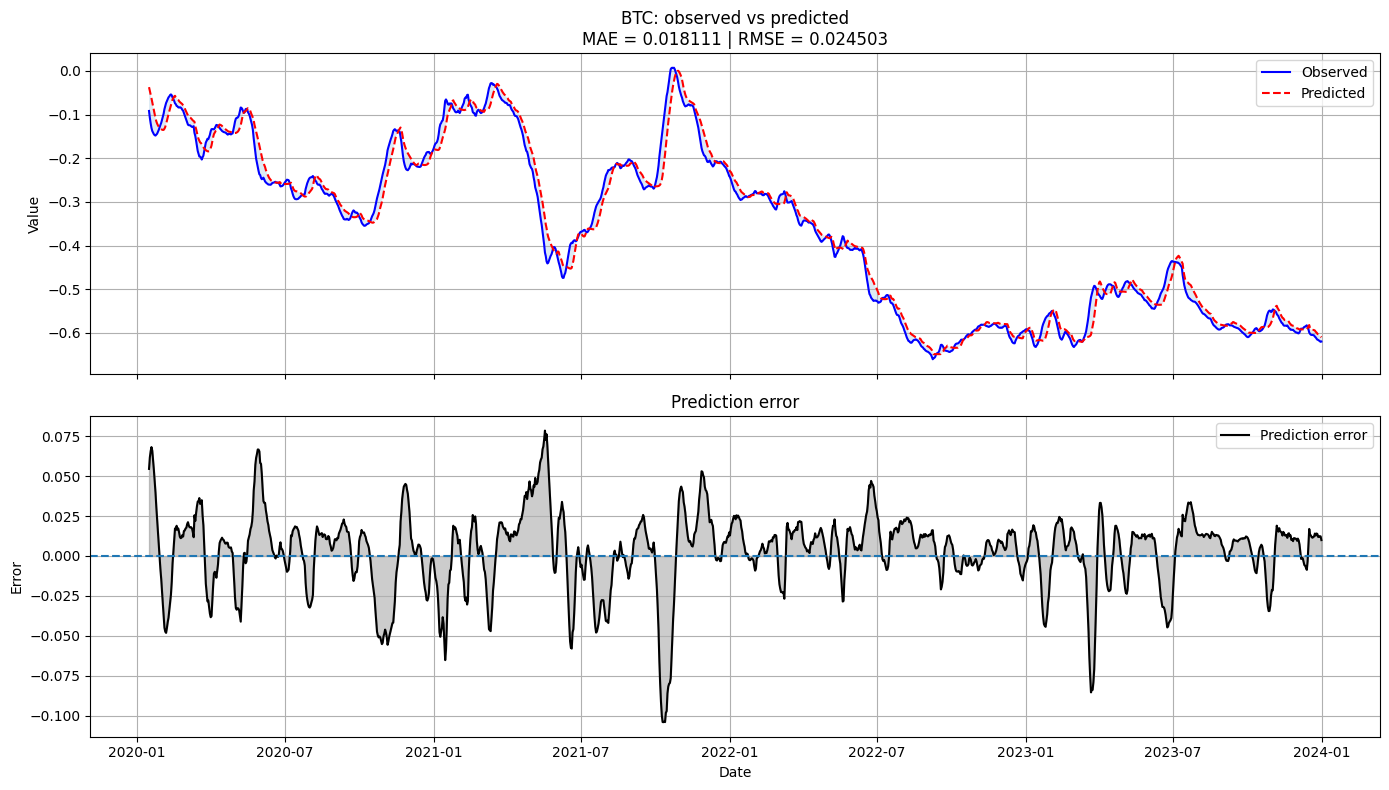

In [132]:

asset = "BTC"

def aux_series_plot(asset):
    # Alignment and cleaning
    comparison = pd.concat(
        [
            aux_series_is_df[asset].rename("Actual"),
            pred_aux_series_is_df[asset].rename("Predicted")
        ],
        axis=1
    ).apply(pd.to_numeric, errors="coerce").dropna()

    comparison.index = pd.to_datetime(comparison.index)
    comparison["Error"] = comparison["Predicted"] - comparison["Actual"]

    # Conversion for fill_between
    x = comparison.index.to_pydatetime()
    actual = comparison["Actual"].to_numpy(dtype=float)
    predicted = comparison["Predicted"].to_numpy(dtype=float)
    error = comparison["Error"].to_numpy(dtype=float)

    # Metrics
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))

    # Charts
    fig, axes = plt.subplots(
        2, 1,
        figsize=(14, 8),
        sharex=True
    )

    axes[0].plot(x, actual, label="Observed",color='blue')
    axes[0].plot(x, predicted, "--", label="Predicted",color='red')
    axes[0].fill_between(x, actual, predicted, alpha=0.15)

    axes[0].set_title(
        f"{asset}: observed vs predicted\n"
        f"MAE = {mae:.6f} | RMSE = {rmse:.6f}"
    )
    axes[0].set_ylabel("Value")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(x, error, label="Prediction error",color='black')
    axes[1].fill_between(x, error, 0, alpha=0.2,color='black')
    axes[1].axhline(0, linestyle="--")

    axes[1].set_title("Prediction error")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Error")
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()


aux_series_plot(asset)



### Note — Model validation on the auxiliary series

Comparing the **predicted** and **observed** auxiliary series shows that the prediction
follows the dynamics of the series. This comparison of levels is only a first visual check:
a naive forecast ($\widehat{aux}_t = aux_{t-1}$) would also track the level closely, so the
relevant test is on the **increments**.

Let's now look at the relationship between the forecasted residuals and the actual residuals.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     933.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.73e-158
Time:                        19:13:57   Log-Likelihood:                 5974.1
No. Observations:                1446   AIC:                        -1.194e+04
Df Residuals:                    1444   BIC:                        -1.193e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.557e-05      0.000      0.151      0.8

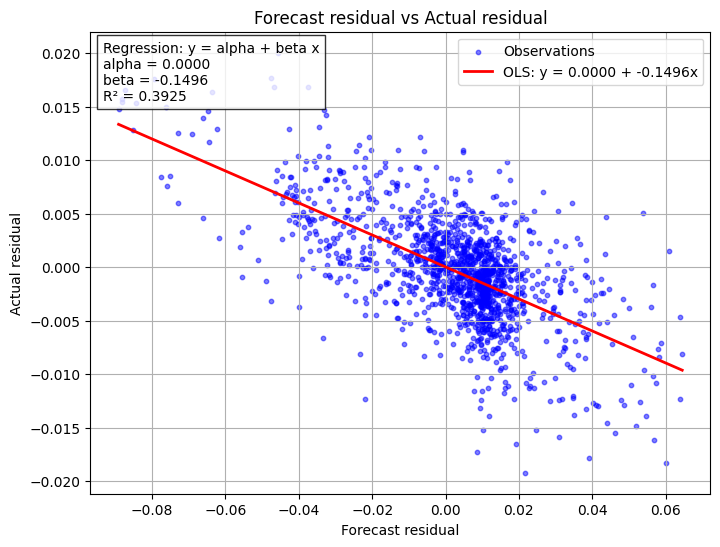

In [133]:
def residuals_plot(
    aux_series,
    aux_series_pred,
):

    #####################################
    # Residuals
    #####################################

    forecast_residual = aux_series_pred - aux_series.shift(1)
    actual_residual = aux_series - aux_series.shift(1)

    x = forecast_residual
    y = actual_residual

    #####################################
    # Cleaning
    #####################################

    reg_df = pd.concat([x, y], axis=1, join="inner")
    reg_df.columns = ["x", "y"]

    reg_df = reg_df.apply(pd.to_numeric, errors="coerce")
    reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna()

    x_clean = reg_df["x"].astype(float)
    y_clean = reg_df["y"].astype(float)

    #####################################
    # classical regression: y = alpha + beta x
    #####################################

    X_reg = sm.add_constant(x_clean)
    Y_reg = y_clean

    model = sm.OLS(Y_reg, X_reg).fit()

    alpha = model.params["const"]
    beta = model.params["x"]
    r2 = model.rsquared

    print(model.summary())

    # regression line
    x_grid = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_hat = alpha + beta * x_grid

    #####################################
    # Residuals plots + OLS line
    #####################################

    plt.figure(figsize=(8, 6))

    plt.scatter(
        x_clean,
        y_clean,
        s=10,
        alpha=0.5,
        label="Observations",
        color='blue'
    )

    plt.plot(
        x_grid,
        y_hat,
        lw=2,
        label=f"OLS: y = {alpha:.4f} + {beta:.4f}x",
        color='red'
    )

    plt.grid()

    plt.xlabel("Forecast residual")
    plt.ylabel("Actual residual")
    plt.title("Forecast residual vs Actual residual")

    txt = (
        f"Regression: y = alpha + beta x\n"
        f"alpha = {alpha:.4f}\n"
        f"beta = {beta:.4f}\n"
        f"R² = {r2:.4f}"
    )

    plt.text(
        0.02,
        0.98,
        txt,
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.legend()
    plt.show()


    return model

residuals_plot(aux_series_is_df.BTC,pred_aux_series_is_df.BTC)

### Note — Signal in the residual tails

For BTC, the scatter shows a **negative linear relationship between predicted and realised
residuals**, with an explained variance of **R² ≈ 0.3** (see the regression output above).

The relationship appears **stronger in the tails**: the bulk of the distribution carries
little information. This suggests a threshold-based implementation, applied asset by asset
(time-series quantiles of each coin's own forecast residual):

| Bucket | Predicted residual | Position |
|---|---|---|
| Top 30 % | Most positive | **Short** |
| Middle 40 % | Near zero | Flat |
| Bottom 30 % | Most negative | **Long** |


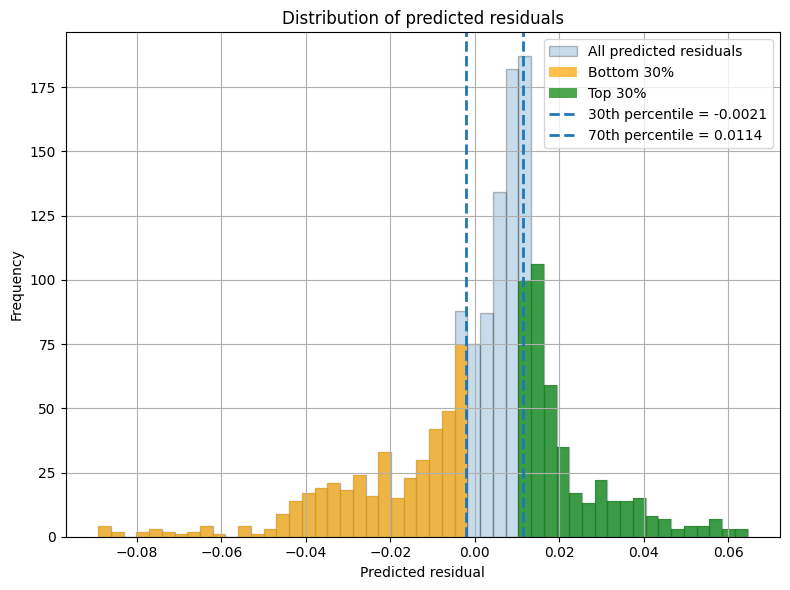

In [134]:
def residuals_hist(
    aux_series,
    aux_series_pred,
):

    #####################################
    # Residuals
    #####################################

    forecast_residual = aux_series_pred - aux_series.shift(1)
    actual_residual = aux_series - aux_series.shift(1)

    x = forecast_residual
    y = actual_residual

    #####################################
    # Cleaning
    #####################################

    reg_df = pd.concat([x, y], axis=1, join="inner")
    reg_df.columns = ["x", "y"]

    reg_df = reg_df.apply(pd.to_numeric, errors="coerce")
    reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna()

    x_clean = reg_df["x"].astype(float)
    y_clean = reg_df["y"].astype(float)


    #####################################
    # Histogram of the predicted residuals
    #####################################

    # Thresholds of the extreme 30%
    bottom_percentile = x_clean.quantile(0.3)
    top_percentile = x_clean.quantile(0.7)

    # Bottom 30%: lowest values
    bottom = x_clean[x_clean <= bottom_percentile]

    # Top 30%: highest values
    top = x_clean[x_clean >= top_percentile]

    # Bins shared by the three histograms
    bins = np.histogram_bin_edges(
        x_clean,
        bins="auto"
    )

    plt.figure(figsize=(8, 6))
    plt.grid()

    # Full distribution
    plt.hist(
        x_clean,
        bins=bins,
        alpha=0.25,
        edgecolor="black",
        label="All predicted residuals"
    )

    # Bottom 30%
    plt.hist(
        bottom,
        bins=bins,
        alpha=0.7,
        label="Bottom 30%",
        color='orange'
    )

    # Top 30%
    plt.hist(
        top,
        bins=bins,
        alpha=0.7,
        label="Top 30%",
        color='green'
    )

    # Percentile thresholds
    plt.axvline(
        bottom_percentile,
        linestyle="--",
        linewidth=2,
        label=f"30th percentile = {bottom_percentile:.4f}"
    )

    plt.axvline(
        top_percentile,
        linestyle="--",
        linewidth=2,
        label=f"70th percentile = {top_percentile:.4f}"
    )

    plt.xlabel("Predicted residual")
    plt.ylabel("Frequency")
    plt.title("Distribution of predicted residuals")


    plt.legend()
    plt.tight_layout()
    plt.show()

residuals_hist(aux_series_is_df.BTC,pred_aux_series_is_df.BTC)

# How the PnL of the strategy is computed
PnL is computed on a daily basis, **position by position**.
A position is opened when the signal becomes non-zero and closed when the signal changes
(back to zero **or** to the opposite side, in which case a new position is opened on the same date).

When a position is opened at date $t_0$, the current price is used as the strike:

$$K = S_{t_0}$$

The number of units is derived from the available notional:

$$N = \frac{\text{Notional}}{K}$$

The **mark-to-market** of the open position at date $t$ is

$$
MtM_t =
\begin{cases}
(S_t-K)\,N, & \text{Long} \\
(K-S_t)\,N, & \text{Short}
\end{cases}
$$

and the **daily PnL** is its variation: $PnL_t = MtM_t - MtM_{t-1}$ (with $MtM_{t_0}=0$),
so that the sum of the daily PnLs of a position equals its realised PnL.

When the position is closed, the realised PnL is added back to the notional:

$$\text{Notional}_{\text{next}} = \text{Notional} + MtM_{\text{close}}$$

The updated notional is then used to size the next position.


In [135]:
def position_segments(signal: pd.Series):
    """
    Split a {-1, 0, +1} signal into positions.
    A position opens when the signal becomes non-zero and closes on the first date
    where the signal changes (to 0 or to the opposite side). A position still open
    at the end of the sample is closed on the last date.
    Returns a list of (open_date, close_date, side).
    """
    s = signal.fillna(0.0)
    change_dates = s.index[s.ne(s.shift(fill_value=0.0))]

    segments = []
    open_date, side = None, 0.0

    for date in change_dates:
        if side != 0:
            segments.append((open_date, date, side))
        side = s.loc[date]
        open_date = date

    if side != 0 and open_date != s.index[-1]:
        segments.append((open_date, s.index[-1], side))

    return segments


def synthetic_asset_payoff(Notional, price, signal):
    """Daily PnL (variation of the mark-to-market) of the signal applied to `price`."""

    synthetic_asset_pnl = pd.Series(0.0, index=signal.index, dtype=float)

    for opening_date, closing_date, pos_type in position_segments(signal):

        path = price.loc[opening_date:closing_date]
        Strike = path.iloc[0]

        if pd.isna(Strike) or Notional <= 0:
            continue

        units = Notional / Strike

        # daily PnL = variation of pos_type * (S_t - K) * units
        daily_pnl = (pos_type * units * path.diff()).iloc[1:].fillna(0.0)
        synthetic_asset_pnl.loc[daily_pnl.index] += daily_pnl

        # realised PnL added back to the notional
        Notional = Notional + daily_pnl.sum()

    return synthetic_asset_pnl


The strategy is now run across the **entire portfolio**, with an **equal allocation of
$1 to every coin**. Each asset is traded independently under its own signal, and the
aggregate PnL is simply the sum of the individual sleeves.

This equal-weight scheme keeps the comparison clean: no coin dominates the result
through size, so the performance reflects the signal itself rather than the allocation.

In [136]:
def signal_generation_in_sample(
    aux_series: pd.Series,
    aux_series_pred,
    top_percentile=0.7,
    bottom_percentile=0.3,
):
    forecast_residual = aux_series_pred - aux_series.shift(1)

    bottom_threshold = forecast_residual.quantile(bottom_percentile)
    top_threshold = forecast_residual.quantile(top_percentile)

    signal = pd.Series(0.0, index=forecast_residual.index)

    signal.loc[forecast_residual <= bottom_threshold] = 1.0
    signal.loc[forecast_residual >= top_threshold] = -1.0

    return signal


signals_is_df = pd.DataFrame(index=returns_is.index)
strategy_pnl_is_df = pd.DataFrame(index=returns_is.index)

for coin in returns.columns:
    signal = signal_generation_in_sample(
        aux_series_is_df[coin],
        pred_aux_series_is_df[coin],
        top_percentile=0.7,
        bottom_percentile=0.3,
    )
    signals_is_df[coin] = signal


# PnL of each coin, starting with a notional of $1
initial_notional_per_asset = 1.0

for coin in returns.columns:

    synthetic_cashflows = synthetic_asset_payoff(
        initial_notional_per_asset,
        price=price[coin].rolling(10).mean(),  # the traded asset is the price moving average
        signal=signals_is_df[coin],
    )

    strategy_pnl_is_df[coin] = synthetic_cashflows.reindex(
        strategy_pnl_is_df.index
    ).fillna(0.0)


Below we present the performance of the strategy: the cumulative PnL of the
portfolio, together with the usual summary statistics — initial capital, final capital, annualised return (CAGR) and Sharpe ratio.

In [137]:

def compute_sharpe_ratio(daily_pnl: pd.Series, periods_per_year=DAYS_PER_YEAR):
    daily_pnl = pd.to_numeric(daily_pnl, errors="coerce").dropna()

    pnl_std = daily_pnl.std()

    if daily_pnl.empty or pnl_std == 0 or pd.isna(pnl_std):
        return np.nan

    return daily_pnl.mean() / pnl_std * np.sqrt(periods_per_year)



def summarize_strategy(
    daily_pnl: pd.Series,
    initial_capital=1.0,
    periods_per_year=DAYS_PER_YEAR,
):
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    stats_df = pd.DataFrame()

    # ---------------------------------------------------------
    # Capital & returns
    # ---------------------------------------------------------

    total_pnl = daily_pnl.sum()

    ending_capital = initial_capital + total_pnl

    n_years = len(daily_pnl) / periods_per_year

    cagr = (
        (ending_capital / initial_capital) ** (1 / n_years) - 1
        if ending_capital > 0 and n_years > 0
        else np.nan
    )

    stats_df["Initial Capital"] = [initial_capital]
    stats_df["Ending Capital"] = [ending_capital]

    stats_df["Total PnL"] = [total_pnl]
    stats_df["CAGR"] = [cagr]
    stats_df["Sharpe ratio"] = [compute_sharpe_ratio(daily_pnl, periods_per_year)]

    return stats_df

portfolio_daily_pnl = strategy_pnl_is_df.sum(axis=1).fillna(0.0)


stats_df = summarize_strategy(
    portfolio_daily_pnl,
    initial_capital=len(signals_is_df.columns),  # the initial capital is $1 times the number of coins
)

print("\n===== In-sample PnL Performance Summary =====\n")
print(stats_df.to_string(index=False))



===== In-sample PnL Performance Summary =====

 Initial Capital  Ending Capital   Total PnL     CAGR  Sharpe ratio
              30     1667.251751 1637.251751 1.736013      4.784802


We visualise the strategy's cumulative PnL for **BTC** with an initial allocation of $1.

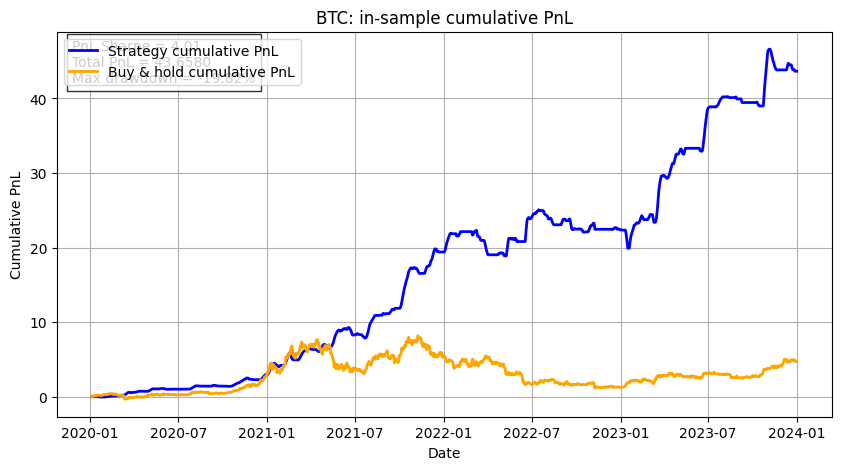

In [138]:

def graphics_plot(
    coin,
    strategy_pnl_df,
    benchmark_returns_df,
    initial_capital=1,
    periods_per_year=DAYS_PER_YEAR,
):
    strategy_daily_pnl = strategy_pnl_df[coin].fillna(0.0)
    strategy_cumulative_pnl = strategy_daily_pnl.cumsum()

    pnl_std = strategy_daily_pnl.std()
    pnl_sharpe = (
        np.nan
        if pnl_std == 0 or pd.isna(pnl_std)
        else strategy_daily_pnl.mean() / pnl_std * np.sqrt(periods_per_year)
    )

    benchmark_returns = benchmark_returns_df[coin].reindex(
        strategy_daily_pnl.index
    ).fillna(0.0)

    benchmark_equity = initial_capital * (1.0 + benchmark_returns).cumprod()
    benchmark_cumulative_pnl = benchmark_equity - initial_capital

    # drawdown in % of the running peak of the equity (initial capital + cumulative PnL)
    strategy_equity = initial_capital + strategy_cumulative_pnl
    strategy_drawdown = strategy_equity / strategy_equity.cummax() - 1.0

    plt.figure(figsize=(10, 5))

    plt.plot(
        strategy_cumulative_pnl.index,
        strategy_cumulative_pnl.values,
        lw=2,
        color="blue",
        label="Strategy cumulative PnL",
    )

    plt.plot(
        benchmark_cumulative_pnl.index,
        benchmark_cumulative_pnl.values,
        lw=2,
        color="orange",
        label="Buy & hold cumulative PnL",
    )

    plt.title(f"{coin}: in-sample cumulative PnL")
    plt.ylabel("Cumulative PnL")
    plt.xlabel("Date")

    txt = (
        f"PnL Sharpe = {pnl_sharpe:.2f}\n"
        f"Total PnL = {strategy_daily_pnl.sum():.4f}\n"
        f"Max drawdown = {strategy_drawdown.min():.2%}"
    )

    plt.text(
        0.02,
        0.98,
        txt,
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.legend()
    plt.grid()
    plt.show()


graphics_plot(
    "BTC",
    strategy_pnl_is_df,
    raw_returns,  # buy & hold uses the raw daily returns, not the 10-day moving average
)



#### These results encourage us to test the strategy out of sample, to assess how it could really perform.
---

##  Out-of-sample analysis
The out-of-sample (OOS) analysis is done on a walk-forward basis with an expanding in-sample window. This approach lets us constantly update the top and bottom percentiles with new observations, which limits overfitting of the thresholds and simulates real trading conditions. The parameters of the `prediction_model` function are kept constant: the model itself acts as a rolling estimator of the residuals. Note that only the thresholds are re-estimated; the number of principal components and the model parameters are fixed.

The following table illustrates the approach.

### Expanding window timeline

| Run | In-sample (train) window | Out-of-sample (test) window |
| :--- | :--- | :--- |
| **Run 1** | Month 1 to Month 12 *(1 year)* | Month 13 to Month 15 *(3 months)* |
| **Run 2** | Month 1 to Month 15 *(1 year + 3 months)* | Month 16 to Month 18 *(3 months)* |
| **Run 3** | Month 1 to Month 18 *(1 year + 6 months)* | Month 19 to Month 21 *(3 months)* |
| **Run 4** | Month 1 to Month 21 *(1 year + 9 months)* | Month 22 to Month 24 *(3 months)* |


***For each run, the in-sample period is used to estimate the top and bottom percentiles, which are then used as thresholds for the out-of-sample period.***


In [139]:
# The model is causal (prediction at t uses data up to t-1), so a single run on the
# full auxiliary series gives the walk-forward predictions.
pred_aux_series_df = pd.DataFrame(index=aux_series_df.index)

for coin in returns.columns:
    aux_series_pred = prediction_model(aux_series_df, coin, normalization_window=10, optimisation_window=10, env_window=0)

    pred_aux_series_df[coin] = aux_series_pred


In [140]:
def signal_generation_oos(aux_series: pd.Series, aux_series_pred, top_threshold, bottom_threshold):

    forecast_residual = aux_series_pred - aux_series.shift(1)

    signal = pd.Series(
        0.0,
        index=forecast_residual.index
    )

    signal.loc[
        forecast_residual <= bottom_threshold
    ] = 1.0

    signal.loc[
        forecast_residual >= top_threshold
    ] = -1.0

    return signal


In [141]:
idx = pd.to_datetime(aux_series_df.index)

# --- WALK-FORWARD CONFIGURATION ---

start_date = idx[0]
train_end = start_date + pd.DateOffset(months=12)

# Expansion step (out-of-sample): 3 months
step_size = pd.DateOffset(months=3)

signals_oos_df = pd.DataFrame(
    0.0,
    index=idx[idx >= train_end],
    columns=aux_series_df.columns,
    dtype=float,
)

# forecast residual of every date (uses only data up to t-1)
forecast_residual_df = pred_aux_series_df - aux_series_df.shift(1)

run = 1

while train_end < idx[-1]:
    test_end = train_end + step_size

    train_idx = idx[
        (idx >= start_date)
        & (idx < train_end)
    ]

    # Thresholds are estimated only from the (expanding) training sample
    bottom_threshold = forecast_residual_df.loc[train_idx].quantile(0.3)
    top_threshold = forecast_residual_df.loc[train_idx].quantile(0.7)

    # Out-of-sample period for this run
    test_idx = idx[
        (idx >= train_end)
        & (idx < test_end)
    ]

    for coin in returns.columns:
        signal = signal_generation_oos(
            aux_series_df[coin],
            pred_aux_series_df[coin],
            top_threshold[coin],
            bottom_threshold[coin],
        ).loc[test_idx]

        signals_oos_df.loc[signal.index, coin] = signal

    train_end += step_size
    run += 1


# --------------------------------------------------------------------------
# PnL calculation
# Signals are first placed on the complete return index so that a position
# opened on the first OOS date is correctly detected.
# --------------------------------------------------------------------------

signals_oos_full_df = pd.DataFrame(
    0.0,
    index=returns.index,
    columns=returns.columns,
)

common_signal_index = signals_oos_full_df.index.intersection(
    signals_oos_df.index
)

signals_oos_full_df.loc[
    common_signal_index,
    signals_oos_df.columns,
] = signals_oos_df.loc[common_signal_index]

strategy_pnl_oos_df = pd.DataFrame(
    0.0,
    index=signals_oos_df.index,
    columns=returns.columns,
)

initial_notional_per_asset = 1.0

for coin in returns.columns:

    coin_daily_pnl = synthetic_asset_payoff(
        initial_notional_per_asset,
        price=price[coin].rolling(10).mean(),
        signal=signals_oos_full_df[coin],
    )

    strategy_pnl_oos_df[coin] = coin_daily_pnl.reindex(
        strategy_pnl_oos_df.index
    ).fillna(0.0)


We can now present the performance of the strategy on out-of-sample data: the cumulative PnL of the
portfolio, together with other statistics — initial capital, final capital, annualised return, Sharpe ratio, profit factor, hit ratio, maximum drawdown, beta against BTC, alpha, etc.

In [ ]:
def returns_to_daily_pnl(
    returns_series: pd.Series,
    initial_capital=1,
):

    returns_series = pd.to_numeric(
        returns_series,
        errors="coerce",
    ).fillna(0.0)

    equity = initial_capital * (1.0 + returns_series).cumprod()
    equity.iloc[0] = initial_capital
    daily_pnl = equity.diff()

    return daily_pnl

def drawdown_series(daily_pnl: pd.Series, initial_capital=1.0):
    """Drawdown in percentage: equity / running peak of the equity - 1,
    with equity = initial capital + cumulative PnL (values in [-1, 0])."""
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    equity = initial_capital + daily_pnl.cumsum()
    running_peak = equity.cummax()

    return equity / running_peak - 1.0



def summarize_strategy_oos(
    daily_pnl: pd.Series,
    benchmark_daily_pnl: pd.Series | None = None,
    initial_capital=1.0,
    periods_per_year=DAYS_PER_YEAR,
):
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    stats_df = pd.DataFrame()

    # ---------------------------------------------------------
    # Capital & returns
    # ---------------------------------------------------------

    total_pnl = daily_pnl.sum()

    ending_capital = initial_capital + total_pnl


    n_years = len(daily_pnl) / periods_per_year

    cagr = (
        (ending_capital / initial_capital) ** (1 / n_years) - 1
        if ending_capital > 0 and n_years > 0
        else np.nan
    )

    average_daily_pnl = daily_pnl.mean()


    stats_df["Initial Capital"] = [initial_capital]
    stats_df["Ending Capital"] = [ending_capital]

    stats_df["Total PnL"] = [total_pnl]
    stats_df["CAGR"] = [cagr]

    stats_df["Average Daily PnL"] = [average_daily_pnl]

    stats_df["PnL Sharpe Ratio"] = [
        compute_sharpe_ratio(
            daily_pnl,
            periods_per_year,
        )
    ]

    # ---------------------------------------------------------
    # Profit factor / hit ratio
    # ---------------------------------------------------------

    profit = daily_pnl[daily_pnl > 0].sum()
    loss = -daily_pnl[daily_pnl < 0].sum()

    profit_factor = profit / loss if loss != 0 else np.inf

    stats_df["Profit Factor"] = [profit_factor]

    # hit ratio computed on the days with an open position only
    active_pnl = daily_pnl[daily_pnl != 0]
    hit_ratio = (active_pnl > 0).mean() if not active_pnl.empty else np.nan

    stats_df["Hit Ratio"] = [hit_ratio]

    # ---------------------------------------------------------
    # Drawdown
    # ---------------------------------------------------------

    drawdown = drawdown_series(daily_pnl, initial_capital)

    duration = (
        (drawdown < 0)
        .groupby((drawdown == 0).cumsum())
        .cumcount()
    )

    stats_df["Max Drawdown (%)"] = [100 * drawdown.min()]

    stats_df["Average Drawdown (%)"] = [
        100 * drawdown[drawdown < 0].mean()
    ]

    stats_df["Max Drawdown Duration"] = [
        duration.max()
    ]

    # ---------------------------------------------------------
    # Benchmark
    # ---------------------------------------------------------

    if benchmark_daily_pnl is not None:

        aligned = pd.concat(
            [
                daily_pnl.rename("strategy_pnl"),
                benchmark_daily_pnl.rename("benchmark_pnl"),
            ],
            axis=1,
            join="inner",
        ).dropna()

        if not aligned.empty:

            benchmark_var = aligned["benchmark_pnl"].var()

            beta = (
                aligned["strategy_pnl"].cov(
                    aligned["benchmark_pnl"]
                )
                / benchmark_var
            )

            daily_alpha_pnl = (
                aligned["strategy_pnl"].mean()
                - beta
                * aligned["benchmark_pnl"].mean()
            )

            stats_df["Benchmark PnL Correlation"] = [
                aligned["strategy_pnl"].corr(
                    aligned["benchmark_pnl"]
                )
            ]

            stats_df["Beta"] = [beta]


            stats_df["Annualized Alpha PnL"] = [
                daily_alpha_pnl * periods_per_year
            ]

    return stats_df

In [143]:
portfolio_daily_pnl = strategy_pnl_oos_df.sum(axis=1).fillna(0.0)

n_coins = len(strategy_pnl_oos_df.columns)

market_returns_oos = raw_returns['BTC'].reindex(portfolio_daily_pnl.index)

# the BTC buy & hold benchmark starts with the same capital as the strategy ($1 per coin)
benchmark_daily_pnl = returns_to_daily_pnl(
    market_returns_oos,
    initial_capital=n_coins,
)

stats_df = summarize_strategy_oos(
    portfolio_daily_pnl,
    benchmark_daily_pnl,
    initial_capital=n_coins,
)

print("\n===== Out-of-sample PnL Performance Summary =====\n")
print(stats_df.to_string(index=True))



===== Out-of-sample PnL Performance Summary =====

   Initial Capital  Ending Capital    Total PnL      CAGR  Average Daily PnL  PnL Sharpe Ratio  Profit Factor  Hit Ratio  Max Drawdown (%)  Average Drawdown (%)  Max Drawdown Duration  Benchmark PnL Correlation      Beta  Annualized Alpha PnL
0               30     1425.890247  1395.890247  1.629156           0.957401          4.578161        3.17602   0.723404        -27.890683             -5.863315                    302                  -0.006207 -0.018095            349.948915


## Synthetic Asset Construction

> ***The main purpose of this construction is to assess the potential feasibility of the approach.***

We construct a **synthetic tradable exposure** using average price options. The replication is based on a classic **option-based synthetic forward structure**.

### Position replication

* **Long synthetic exposure**
  A long position is obtained by buying an at-the-money (ATM) call and selling an ATM put:

   $$V^{\text{long}} = C_{\text{atm}} - P_{\text{atm}}$$

* **Short synthetic exposure**
  A short position is obtained by selling an ATM call and buying an ATM put:

    $$V^{\text{short}} = P_{\text{atm}} - C_{\text{atm}}$$

### Pricing framework

The option premiums are estimated with the **Black-Scholes pricing framework**. This allows the trading signal to be converted into a synthetic exposure with an explicit cost.

#### A first estimator
Although the Black-Scholes model is designed for European vanilla options, it is used here as a **first estimator**. Because the strike is set to the underlying level at the calculation date ($K = S_t$), the formula provides a simple, instantaneous proxy for premium estimation, without the computational burden of exotic closed-form approximations or Monte Carlo simulations.

#### Frictions and realism
Due to the exotic and over-the-counter (OTC) nature of average price options, we cannot confidently define **commissions**, because of the lack of public centralised benchmarks.

In order to maintain backtest realism and compensate for the absence of commissions, we apply a range of **slippage penalties** to simulate bid-ask spreads.

## Synthetic exposure with slippages

Option premiums are computed using a Black-Scholes framework with the following inputs:
* $S_t$: current underlying level
* $K$: ATM strike price
* $r_t$: risk-free rate (aligned with the return index and forward-filled)
* $\sigma_t$: annualised rolling volatility (estimated from the historical log-returns of the underlying, 365-day convention)
* $T$: time to maturity (in years, 365-day convention)
* $C$: the call option premium
* $P$: the put option premium

---

### 1. Position Opening

The opening cost of a long synthetic exposure, incorporating the execution slippage $s$, is:

$$V^{\text{long}}= C_{\text{ask}} - P_{\text{bid}}$$

Where bid and ask prices are derived from mid-prices:

$$C_{\text{ask}} = C_{\text{mid}}(1 + s)$$
$$P_{\text{bid}} = P_{\text{mid}}(1 - s)$$

Thus, the total net opening cost is expressed as:

$$
\begin{aligned}
V^{\text{long}}
&= C_{\text{ask}} - P_{\text{bid}} \\[4pt]
&= C_{\text{mid}}(1+s) - P_{\text{mid}}(1-s) \\[4pt]
&= \underbrace{\left(C_{\text{mid}}-P_{\text{mid}}\right)}_{\text{mid-price synthetic}}
 \;+\; \underbrace{\left(C_{\text{mid}}+P_{\text{mid}}\right)s}_{\text{transaction cost}}
\end{aligned}
$$
Similarly, for a short exposure:
$$
\begin{aligned}
V^{\text{Short}}
&= P_{\text{ask}} - C_{\text{bid}} \\[4pt]
&= P_{\text{mid}}(1+s) - C_{\text{mid}}(1-s) \\[4pt]
&= \underbrace{\left(P_{\text{mid}}-C_{\text{mid}}\right)}_{\text{mid-price synthetic}}
 \;+\; \underbrace{\left(C_{\text{mid}}+P_{\text{mid}}\right)s}_{\text{transaction cost}}
\end{aligned}
$$
---



### 2. Early Closing (Prior to Maturity)

If a position is liquidated before expiration, the synthetic contract is unwound in the market. The options must be re-priced using the exact remaining time to maturity ($T_{\text{remaining}}$):

$$T_{\text{remaining}} = \frac{\text{Maturity Date} - \text{Closing Date}}{365}$$

For example, when exiting a long synthetic exposure, the position is closed by selling the call at the **bid** price and buying the put at the **ask** price, with a maturity of $T_{\text{remaining}}$ and the original strike $K$. The cost of the unwind is again $(C_{\text{mid}}+P_{\text{mid}})\,s$.

---

### 3. Settlement at Maturity

If the position is held until expiry and the signal is still non-zero, the options settle at expiry (no unwind cost) and a new position is opened at the new ATM strike, in order to maintain the exposure.




In [144]:
# ==========================================================================
# Identify the dates for opening, renewing or closing the positions
# ==========================================================================
def build_position_dates(signal, maturity_days=10, day_count=DAYS_PER_YEAR):

    position_calendar = pd.DataFrame()
    open_dates = []       # opening dates
    close_dates = []      # closing dates
    sides = []            # +1 long, -1 short
    renewals = []         # True if the closing date is the maturity of the contract (position renewed)
    remaining_days = []   # remaining days to maturity at the closing date
    remaining_times = []  # remaining_days / day_count

    for start, end, side in position_segments(signal):

        open_ = start

        # the signal lasts longer than the maturity: the contract is renewed at each maturity date
        while open_ + pd.Timedelta(days=maturity_days) < end:
            renewal_date = open_ + pd.Timedelta(days=maturity_days)

            open_dates.append(open_)
            close_dates.append(renewal_date)
            sides.append(side)
            renewals.append(True)
            remaining_days.append(0)          # the contract reaches its maturity
            remaining_times.append(0.0)

            open_ = renewal_date

        # last (or only) contract, closed before or at its maturity
        rem_days = (open_ + pd.Timedelta(days=maturity_days) - end).days
        open_dates.append(open_)
        close_dates.append(end)
        sides.append(side)
        renewals.append(False)
        remaining_days.append(rem_days)
        remaining_times.append(round(rem_days / day_count, 4))

    position_calendar["open_date"] = open_dates
    position_calendar["close_date"] = close_dates
    position_calendar["side"] = sides
    position_calendar["renewal"] = renewals
    position_calendar["remaining_days"] = remaining_days
    position_calendar["remaining_time"] = remaining_times

    return position_calendar


In [145]:
# ==========================================================================
# - Black Scholes function and importing risk-free rates
# ==========================================================================
from scipy.stats import norm
from pandas_datareader import data as web
def blackScholes(r, S, K, T, sigma, option_type="c"):
    "Calculate BS price of call/put"
    # r : risk free rate
    # S : current price
    # K : strike price
    # T : time to maturity (in years)
    # sigma : volatility
    # option_type : 'c' for call, 'p' for put

    option_type = option_type.lower()

    if option_type not in ["c", "p"]:
        raise ValueError("option_type must be 'c' for Call or 'p' for Put")

    if sigma <= 0 or T <= 0:
        return 0

    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "c":
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

    return price


start = "2019-01-01"
end = "2026-06-23"

# US 3-month Treasury rate
rf = web.DataReader("DGS3MO", "fred", start, end)

rf = rf.rename(columns={"DGS3MO": "rf_annual"})
rf = rf.dropna()

# treasury rates in decimal
rf["rf_annual"] = rf["rf_annual"] / 100



In [146]:
# ==========================================================================
# - Daily PnL of the synthetic forward, net of slippage on the option premiums
# ==========================================================================

def synthetic_asset_payoff_with_slip(position_calendar_df, price, rf, mat_period, vol_window, slippage, initial_notional=1.0):

    synthetic_asset_pnl = pd.Series(0.0, index=price.index, dtype=float)

    # risk-free rate on the daily calendar (weekends / holidays forward-filled)
    rf_daily = rf.reindex(rf.index.union(price.index)).ffill().reindex(price.index)
    volatility = np.log(price).diff().rolling(window=vol_window, min_periods=2).std() * np.sqrt(DAYS_PER_YEAR)

    T = mat_period / DAYS_PER_YEAR

    Notional = initial_notional
    units = None          # number of units, fixed over a whole signal period (renewals included)
    position_pnl = 0.0    # PnL accumulated since the start of the current signal period

    for row in position_calendar_df.itertuples(index=False):

        opening_date, closing_date, pos_type = row.open_date, row.close_date, row.side

        path = price.loc[opening_date:closing_date]
        Strike = path.iloc[0]

        if pd.isna(Strike) or Notional <= 0:
            continue

        # sizing at the start of the signal period only: a renewal keeps the same exposure,
        # so that with a 0% slippage the net PnL equals the gross PnL
        if units is None:
            units = Notional / Strike

        # opening the position: slippage paid on both legs, (C + P) * s
        call_premium = blackScholes(rf_daily[opening_date], Strike, Strike, T, volatility.loc[opening_date], option_type="c")
        put_premium = blackScholes(rf_daily[opening_date], Strike, Strike, T, volatility.loc[opening_date], option_type="p")
        opening_cost = (call_premium + put_premium) * slippage * units

        # daily PnL of the synthetic forward: C - P = S - K, so its variation is the variation of S
        daily_pnl = (pos_type * units * path.diff()).fillna(0.0)
        daily_pnl.iloc[0] -= opening_cost

        # closing the position before maturity: the options (strike K) are unwound with slippage
        if not row.renewal:
            remaining_time = row.remaining_days / DAYS_PER_YEAR
            S_close = price.loc[closing_date]
            call_close = blackScholes(rf_daily[closing_date], S_close, Strike, remaining_time, volatility.loc[closing_date], option_type="c")
            put_close = blackScholes(rf_daily[closing_date], S_close, Strike, remaining_time, volatility.loc[closing_date], option_type="p")
            daily_pnl.iloc[-1] -= (call_close + put_close) * slippage * units

        synthetic_asset_pnl.loc[daily_pnl.index] += daily_pnl

        position_pnl += daily_pnl.sum()

        # end of the signal period: realised PnL added back to the notional
        if not row.renewal:
            Notional = Notional + position_pnl
            units = None
            position_pnl = 0.0

    return synthetic_asset_pnl


### Sensitivity to slippage

The objective is to see how the strategy performs under different slippage assumptions.

In [147]:
# ==========================================================================
# Step 0 - Gross and net PnL portfolio construction
# ==========================================================================

signals_df = signals_oos_full_df.copy()

strategy_gross_pnl_df = strategy_pnl_oos_df.copy()

slippages = np.concatenate(([0], np.arange(0.05, 0.4, 0.1)))   # 0%, 5%, 15%, 25%, 35%
selected_slippage = slippages[2]                              # 15%, used for the detailed analysis

net_pnl_by_slippage = {}   # slippage -> DataFrame of the daily net PnL of each coin
pnl_after_slippage_df = pd.DataFrame(index=strategy_gross_pnl_df.index, columns=slippages, dtype=float)

# the position calendar does not depend on the slippage: computed once per coin
position_calendars = {coin: build_position_dates(signals_df[coin]) for coin in returns.columns}

for slippage in slippages:
    coin_net_pnl_df = pd.DataFrame(0.0, index=strategy_gross_pnl_df.index, columns=strategy_gross_pnl_df.columns)

    for coin in returns.columns:
        pnl_cashflows = synthetic_asset_payoff_with_slip(
            position_calendars[coin],
            price[coin].rolling(10).mean(),
            rf["rf_annual"],
            mat_period=10,
            vol_window=30,
            slippage=slippage,
        )

        coin_net_pnl_df[coin] = pnl_cashflows.reindex(coin_net_pnl_df.index).fillna(0.0)

    net_pnl_by_slippage[slippage] = coin_net_pnl_df
    pnl_after_slippage_df[slippage] = coin_net_pnl_df.sum(axis=1)


# Net PnL of each coin and of the portfolio for the selected slippage
strategy_net_pnl_df = net_pnl_by_slippage[selected_slippage]
portfolio_net_daily_pnl = strategy_net_pnl_df.sum(axis=1)

# Equal-weighted portfolio gross PnL
portfolio_gross_daily_pnl = strategy_gross_pnl_df.sum(axis=1)


# BTC buy & hold benchmark on the same initial capital ($1 per coin)
market_returns = raw_returns['BTC'].reindex(
    portfolio_gross_daily_pnl.index
)

benchmark_daily_pnl = returns_to_daily_pnl(
    market_returns,
    initial_capital=n_coins,
)


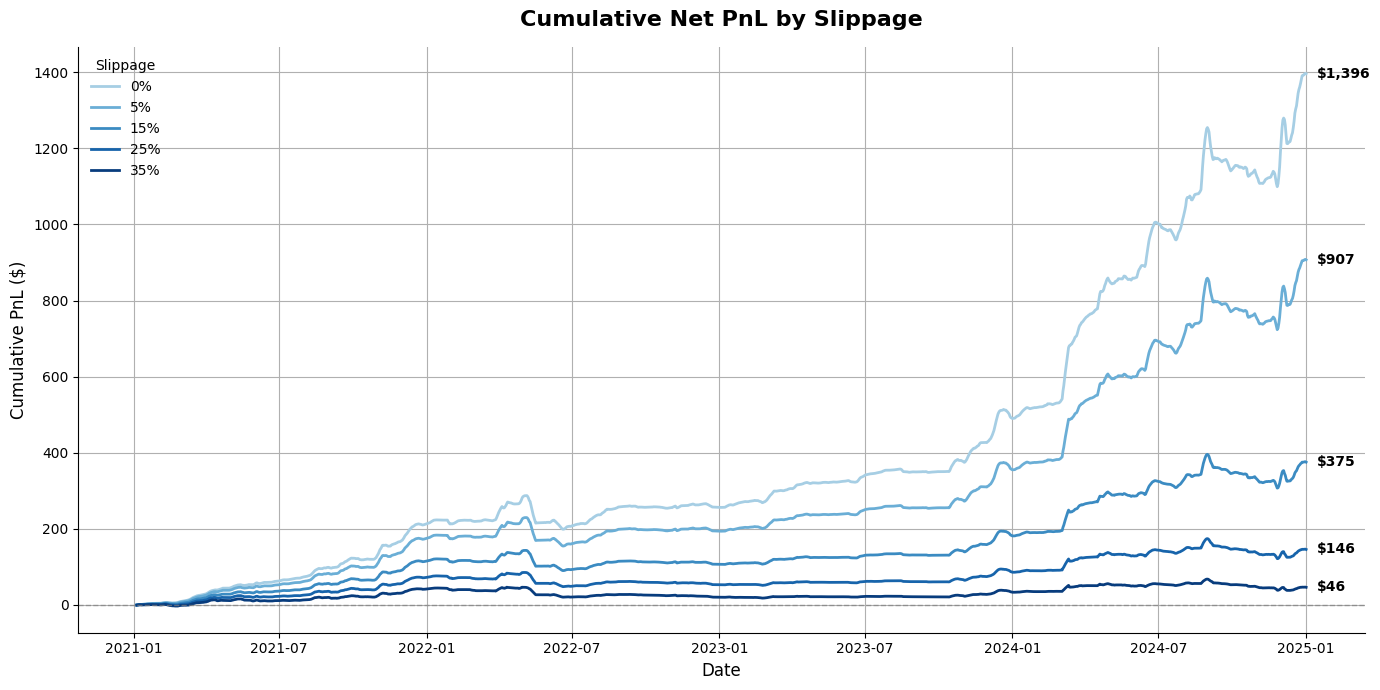

In [166]:
# ==========================================================================
# Cumulative net PnL of the portfolio for each slippage assumption
# ==========================================================================

cumulative_pnl = pnl_after_slippage_df.cumsum()

# one hue, light -> dark: the darker the line, the higher the slippage
slippage_colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(slippages)))

fig, ax = plt.subplots(figsize=(14, 7))

for color, slippage in zip(slippage_colors, cumulative_pnl.columns):
    ax.plot(
        cumulative_pnl.index,
        cumulative_pnl[slippage],
        color=color,
        linewidth=2,
        label=f"{slippage:.0%}",
    )

    # final value written at the end of each line
    final_value = cumulative_pnl[slippage].iloc[-1]
    ax.annotate(
        f"${final_value:,.0f}",
        xy=(cumulative_pnl.index[-1], final_value),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

ax.axhline(y=0, color="grey", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("Cumulative Net PnL by Slippage", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Cumulative PnL ($)", fontsize=12)
ax.grid(True)
ax.legend(title="Slippage", frameon=False, fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



===== Performance by slippage =====

          Total Net PnL ($)  Net Sharpe Ratio  Max Drawdown (%)
Slippage                                                       
0%                  1395.89              4.58            -27.89
5%                   906.84              4.22            -28.85
15%                  375.33              3.36            -30.67
25%                  145.89              2.34            -32.32
35%                   46.46              1.25            -37.32


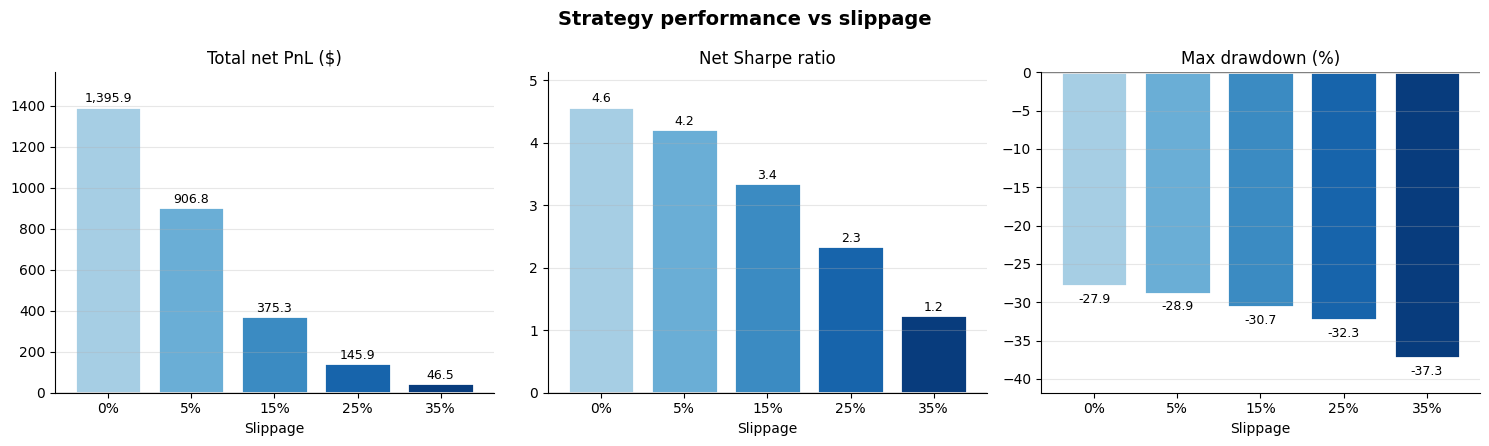

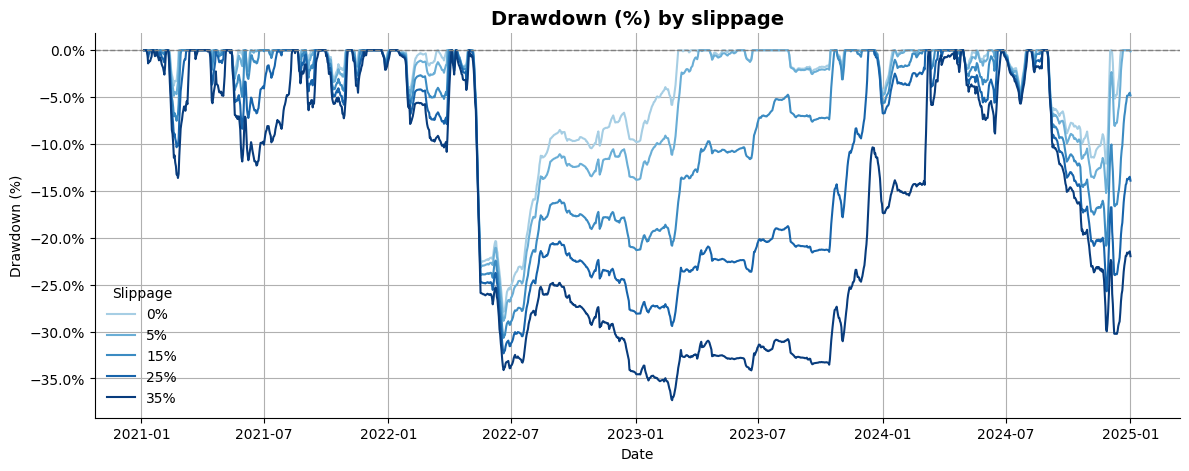

In [165]:
# ==========================================================================
# Performance and drawdown (%) as a function of the slippage
# ==========================================================================
from matplotlib.ticker import PercentFormatter

slippage_summary = []
drawdown_by_slippage = pd.DataFrame(index=pnl_after_slippage_df.index, columns=slippages, dtype=float)

for slippage in slippages:
    daily = pnl_after_slippage_df[slippage]
    dd = drawdown_series(daily, initial_capital=n_coins)
    drawdown_by_slippage[slippage] = dd
    slippage_summary.append({
        "Slippage": slippage,
        "Total Net PnL ($)": daily.sum(),
        "Net Sharpe Ratio": compute_sharpe_ratio(daily, DAYS_PER_YEAR),
        "Max Drawdown (%)": 100 * dd.min(),
    })

slippage_summary_df = pd.DataFrame(slippage_summary).set_index("Slippage")

print("\n===== Performance by slippage =====\n")
print(slippage_summary_df.rename(index=lambda s: f"{s:.0%}").round(2).to_string())

# --- 1) three metrics vs slippage (one chart per metric, no dual axis)
labels = [f"{s:.0%}" for s in slippages]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metrics = [
    ("Total Net PnL ($)", "Total net PnL ($)"),
    ("Net Sharpe Ratio", "Net Sharpe ratio"),
    ("Max Drawdown (%)", "Max drawdown (%)"),
]


for ax, (col, title) in zip(axes, metrics):
    values = slippage_summary_df[col].values
    ax.bar(labels, values, color=slippage_colors, edgecolor="white", linewidth=2)
    for x, v in zip(range(len(labels)), values):
        ax.annotate(f"{v:,.1f}", xy=(x, v), xytext=(0, 3 if v >= 0 else -12),
                    textcoords="offset points", ha="center", fontsize=9)
    ax.axhline(0, color="grey", linewidth=1)
    ax.margins(y=0.12)
    ax.set_title(title)
    ax.set_xlabel("Slippage")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Strategy performance vs slippage", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- 2) drawdown (%) over time for each slippage
fig, ax = plt.subplots(figsize=(14, 5))
for color, slippage in zip(slippage_colors, slippages):
    ax.plot(drawdown_by_slippage.index, drawdown_by_slippage[slippage], color=color, linewidth=1.5, label=f"{slippage:.0%}")
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Drawdown (%) by slippage", fontsize=14, fontweight="bold")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.legend(title="Slippage", frameon=False)
ax.grid(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#plt.tight_layout()

plt.show()


### Slippage analysis

The slippage analysis shows that performance degrades quickly as the slippage rises: the strategy is sensitive to slippage.

Without further improvements, the strategy could not easily be implemented.


### Performance analysis

We now analyse the overall performance of the strategy for a small slippage (15%).

The main measures are total and annualised PnL, the Sharpe ratio, profit factor, hit ratio, drawdown in percentage of the equity peak, beta, alpha, and information ratio relative to a BTC buy-and-hold benchmark with the same initial capital.

The strategy portfolio is equally weighted across the selected cryptocurrencies: each asset begins with the same normalised notional ($1).


===== PnL Performance Summary with a slippage of 15% =====

                    Initial Capital  Ending Capital   Total PnL      CAGR  Average Daily PnL  PnL Sharpe Ratio  Profit Factor  Hit Ratio  Max Drawdown (%)  Average Drawdown (%)  Max Drawdown Duration  Benchmark PnL Correlation      Beta  Annualized Alpha PnL
Strategy - Net PnL               30      405.325477  375.325477  0.918927           0.257425          3.360271       2.025128   0.628944        -30.669315             -9.445016                    535                   0.007839  0.008371          9.393331e+01
Buy and Hold PnL                 30       86.872184   56.872184  0.304963           0.039007          0.543781       1.090325   0.496911        -78.920967            -40.002319                    846                   1.000000  1.000000         -2.532696e-15


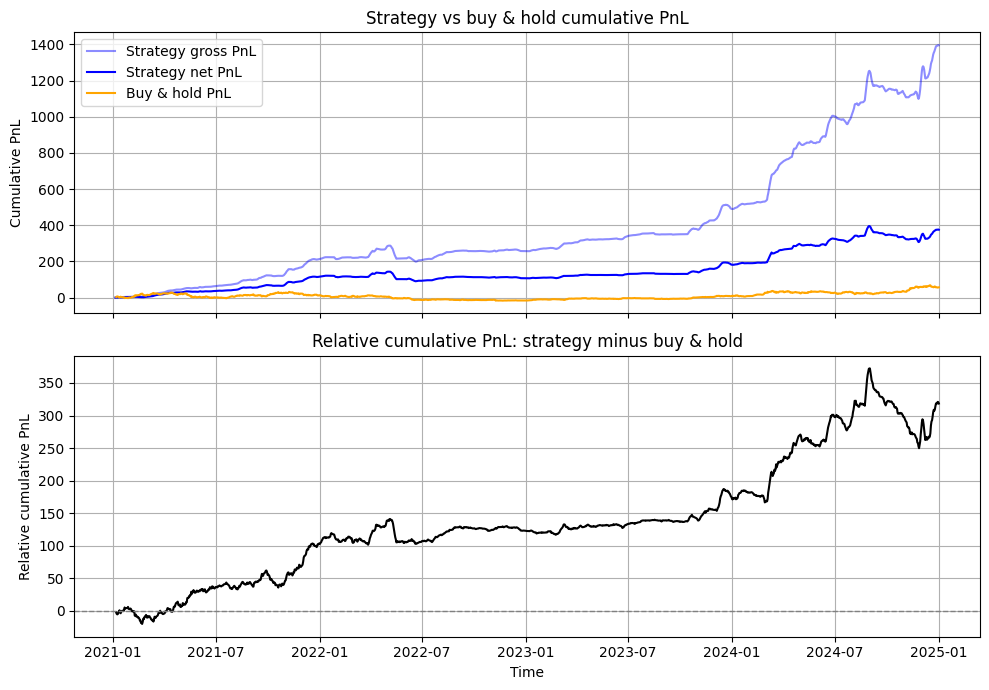

In [150]:
# ==========================================================================
# Step 1 - PnL analysis against buy and hold
# ==========================================================================

# Convenience alias
portfolio_daily_pnl = portfolio_net_daily_pnl  # slippage of 15%


strategy_stats_df = summarize_strategy_oos(
    portfolio_daily_pnl,
    benchmark_daily_pnl,
    initial_capital=n_coins,
)

buy_hold_stats_df = summarize_strategy_oos(
    benchmark_daily_pnl,
    benchmark_daily_pnl,
    initial_capital=n_coins,
)

stats_df = pd.concat(
    [strategy_stats_df, buy_hold_stats_df],
    axis=0,
)

stats_df.index = [
    "Strategy - Net PnL",
    "Buy and Hold PnL",
]

print(f"\n===== PnL Performance Summary with a slippage of {selected_slippage:.0%} =====\n")
print(stats_df.to_string(index=True))


gross_cumulative_pnl = portfolio_gross_daily_pnl.cumsum()
net_cumulative_pnl = portfolio_daily_pnl.cumsum()
benchmark_cumulative_pnl = benchmark_daily_pnl.cumsum()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

# Plot 1: cumulative PnL
axes[0].plot(
    gross_cumulative_pnl,
    label="Strategy gross PnL",
    color="blue",
    alpha=0.45,
)

axes[0].plot(
    net_cumulative_pnl,
    label="Strategy net PnL",
    color="blue",
)

axes[0].plot(
    benchmark_cumulative_pnl,
    label="Buy & hold PnL",
    color="orange",
)

axes[0].set_title("Strategy vs buy & hold cumulative PnL")
axes[0].set_ylabel("Cumulative PnL")
axes[0].legend()
axes[0].grid(True)

# Plot 2: relative cumulative PnL
relative_cumulative_pnl = (
    net_cumulative_pnl
    - benchmark_cumulative_pnl
)

axes[1].plot(
    relative_cumulative_pnl,
    color="black",
)

axes[1].axhline(
    0.0,
    color="grey",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Relative cumulative PnL: strategy minus buy & hold"
)
axes[1].set_ylabel("Relative cumulative PnL")
axes[1].set_xlabel("Time")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [151]:


def drawdown_analysis(daily_pnl: pd.Series, initial_capital=1.0):
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    drawdown_df = pd.DataFrame()

    drawdown_pct = drawdown_series(daily_pnl, initial_capital)

    duration = (
        (drawdown_pct < 0)
        .groupby((drawdown_pct == 0).cumsum())
        .cumcount()
    )

    drawdown_df["Max Drawdown (%)"] = [
        100 * drawdown_pct.min()
    ]
    drawdown_df["Max Drawdown Duration"] = [
        duration.max()
    ]
    drawdown_df["Average Drawdown (%)"] = [
        100 * drawdown_pct[drawdown_pct < 0].mean()
    ]
    drawdown_df["Average Drawdown Duration"] = [
        duration[drawdown_pct < 0].mean()
    ]

    return drawdown_df



===== Drawdown Analysis (slippage of 15%) =====

 Max Drawdown (%)  Max Drawdown Duration  Average Drawdown (%)  Average Drawdown Duration
       -30.669315                    535             -9.445016                  142.06921


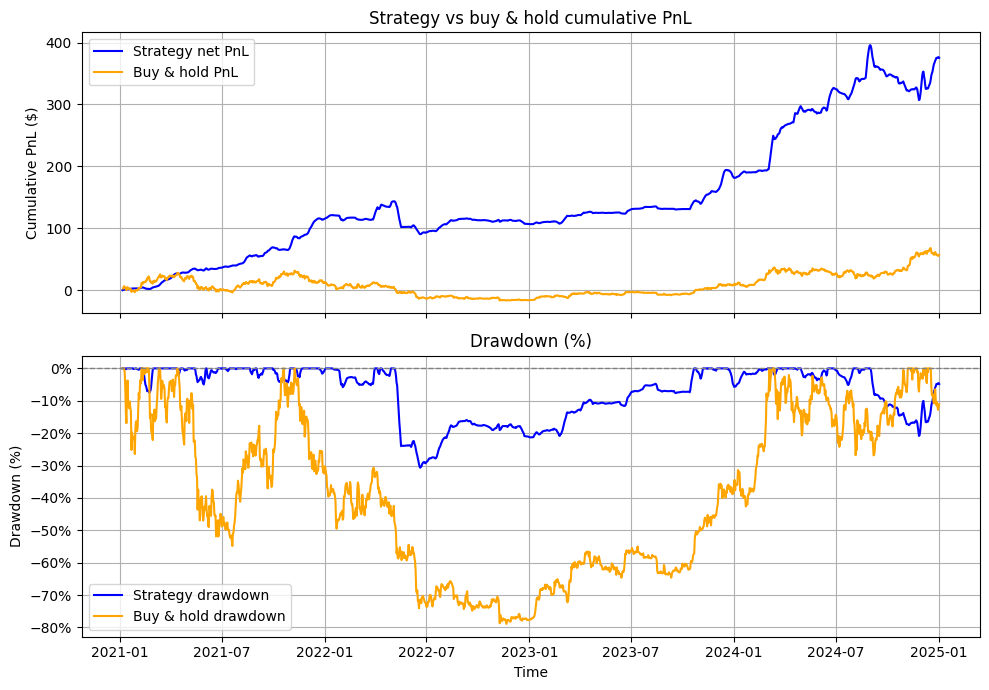

In [152]:
# ==========================================================================
# Step 2 - Drawdown analysis (%) against buy and hold
# ==========================================================================
from matplotlib.ticker import PercentFormatter

drawdown_stats = drawdown_analysis(
    portfolio_net_daily_pnl,
    initial_capital=n_coins,
)

print(f"\n===== Drawdown Analysis (slippage of {selected_slippage:.0%}) =====\n")
print(drawdown_stats.to_string(index=False))

strategy_cumulative_pnl = portfolio_net_daily_pnl.cumsum()
benchmark_cumulative_pnl = benchmark_daily_pnl.cumsum()

strategy_drawdown_pct = drawdown_series(portfolio_net_daily_pnl, initial_capital=n_coins)
benchmark_drawdown_pct = drawdown_series(benchmark_daily_pnl, initial_capital=n_coins)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

# Plot 1: cumulative PnL
axes[0].plot(strategy_cumulative_pnl, label="Strategy net PnL", color="blue")
axes[0].plot(benchmark_cumulative_pnl, label="Buy & hold PnL", color="orange")
axes[0].set_title("Strategy vs buy & hold cumulative PnL")
axes[0].set_ylabel("Cumulative PnL ($)")
axes[0].legend()
axes[0].grid(True)

# Plot 2: drawdown in %
axes[1].plot(strategy_drawdown_pct, label="Strategy drawdown", color="blue")
axes[1].plot(benchmark_drawdown_pct, label="Buy & hold drawdown", color="orange")
axes[1].axhline(0.0, color="grey", linestyle="--", linewidth=1)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Drawdown (%)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [153]:
# ==========================================================================
# Step 3 - Alpha contribution analysis in PnL units
# ==========================================================================

import statsmodels.api as sm

regression_df = pd.concat(
    [
        portfolio_net_daily_pnl.rename("strategy_pnl"),
        benchmark_daily_pnl.rename("benchmark_pnl"),
    ],
    axis=1,
    join="inner",
).fillna(0.0)

X = sm.add_constant(
    regression_df["benchmark_pnl"]
)

Y = regression_df["strategy_pnl"]

model = sm.OLS(Y, X).fit()

beta = model.params["benchmark_pnl"]
daily_alpha_pnl = model.params["const"]
annualized_alpha_pnl = daily_alpha_pnl * DAYS_PER_YEAR
alpha_tstat = model.tvalues["const"]

active_pnl = (
    regression_df["strategy_pnl"]
    - beta * regression_df["benchmark_pnl"]
)

active_pnl_std = active_pnl.std()

information_ratio = (
    np.nan
    if active_pnl_std == 0 or pd.isna(active_pnl_std)
    else active_pnl.mean()
    / active_pnl_std
    * np.sqrt(DAYS_PER_YEAR)
)

print("\n===== Alpha PnL Contribution Analysis =====\n")
print(f"Daily Alpha PnL: {daily_alpha_pnl:.6f}")
print(f"PnL Beta vs buy and hold: {beta:.4f}")
print(f"Annualized Alpha PnL: {annualized_alpha_pnl:.6f}")
print(f"Alpha t-statistic: {alpha_tstat:.2f}")
print(f"PnL Information Ratio: {information_ratio:.2f}")



===== Alpha PnL Contribution Analysis =====

Daily Alpha PnL: 0.257098
PnL Beta vs buy and hold: 0.0084
Annualized Alpha PnL: 93.840821
Alpha t-statistic: 6.70
PnL Information Ratio: 3.36


### General summary of the residual strategy's PnL metrics


In [154]:
def general_summarize_strategy(
    gross_daily_pnl: pd.Series,
    net_daily_pnl: pd.Series,
    signals_df: pd.DataFrame,
    benchmark_daily_pnl: pd.Series,
    initial_capital=1.0,
    periods_per_year=DAYS_PER_YEAR,
):
    stats_df = pd.DataFrame()

    gross_daily_pnl = pd.to_numeric(
        gross_daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    net_daily_pnl = pd.to_numeric(
        net_daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    stats_df["Gross Total PnL"] = [
        gross_daily_pnl.sum()
    ]
    stats_df["Net Total PnL"] = [
        net_daily_pnl.sum()
    ]

    stats_df["Gross PnL Sharpe Ratio"] = [
        compute_sharpe_ratio(
            gross_daily_pnl,
            periods_per_year,
        )
    ]

    stats_df["Net PnL Sharpe Ratio"] = [
        compute_sharpe_ratio(
            net_daily_pnl,
            periods_per_year,
        )
    ]

    turnover = (
        (signals_df - signals_df.shift())
        .abs()
        .sum(axis=1)
        / len(signals_df.columns)
    )

    stats_df["Average Turnover"] = [
        turnover.mean()
    ]

    stats_df["Annualized Net PnL"] = [
        net_daily_pnl.mean() * periods_per_year
    ]

    stats_df["Annualized PnL Volatility"] = [
        net_daily_pnl.std()
        * np.sqrt(periods_per_year)
    ]

    net_drawdown_pct = drawdown_series(
        net_daily_pnl,
        initial_capital,
    )

    stats_df["Max Drawdown (%)"] = [
        100 * net_drawdown_pct.min()
    ]

    active_net_pnl = net_daily_pnl[
        net_daily_pnl != 0
    ]

    stats_df["Hit Ratio"] = [
        np.nan
        if active_net_pnl.empty
        else (active_net_pnl > 0).mean()
    ]

    regression_df = pd.concat(
        [
            net_daily_pnl.rename("strategy_pnl"),
            benchmark_daily_pnl.rename("benchmark_pnl"),
        ],
        axis=1,
        join="inner",
    ).fillna(0.0)

    stats_df["Benchmark PnL Correlation"] = [
        regression_df["strategy_pnl"].corr(
            regression_df["benchmark_pnl"]
        )
    ]

    X = sm.add_constant(
        regression_df["benchmark_pnl"]
    )

    Y = regression_df["strategy_pnl"]

    model = sm.OLS(Y, X).fit()

    beta = model.params["benchmark_pnl"]
    daily_alpha_pnl = model.params["const"]

    stats_df["PnL Beta"] = [beta]
    stats_df["Annualized Alpha PnL"] = [
        daily_alpha_pnl * periods_per_year
    ]
    stats_df["Alpha t-statistic"] = [
        model.tvalues["const"]
    ]

    active_pnl = (
        regression_df["strategy_pnl"]
        - beta * regression_df["benchmark_pnl"]
    )

    active_pnl_std = active_pnl.std()

    stats_df["PnL Information Ratio"] = [
        np.nan
        if active_pnl_std == 0
        or pd.isna(active_pnl_std)
        else active_pnl.mean()
        / active_pnl_std
        * np.sqrt(periods_per_year)
    ]

    return stats_df


In [155]:
gross_portfolio_daily_pnl = strategy_gross_pnl_df.sum(axis=1)
net_portfolio_daily_pnl = strategy_net_pnl_df.sum(axis=1)

stats_df = general_summarize_strategy(
    gross_daily_pnl=gross_portfolio_daily_pnl,
    net_daily_pnl=net_portfolio_daily_pnl,
    signals_df=signals_oos_df,
    benchmark_daily_pnl=benchmark_daily_pnl,
    initial_capital=n_coins,
)


In [156]:
print("\n===== General PnL Analysis =====\n")
print(stats_df.to_string(index=False))



===== General PnL Analysis =====

 Gross Total PnL  Net Total PnL  Gross PnL Sharpe Ratio  Net PnL Sharpe Ratio  Average Turnover  Annualized Net PnL  Annualized PnL Volatility  Max Drawdown (%)  Hit Ratio  Benchmark PnL Correlation  PnL Beta  Annualized Alpha PnL  Alpha t-statistic  PnL Information Ratio
     1395.890247     375.325477                4.578161              3.360271               0.1           93.960082                  27.962057        -30.669315   0.628944                   0.007843  0.008376             93.840821             6.7026               3.356109


---

Beyond the PnL Sharpe ratio, the beta of the strategy against the BTC buy-and-hold benchmark should be close to zero: this is consistent with the strategy's design, which trades residual components rather than the directional movement of the underlying assets.

The alpha is therefore expressed as an incremental daily and annualised PnL after controlling for the buy-and-hold benchmark's PnL.

---


# Conclusion: asset selection and market feasibility

Even though we have established the theoretical framework to construct a synthetic tradable exposure via an option-based synthetic forward structure, market microstructure imposes significant practical constraints.

In particular, we strongly doubt that an active, liquid institutional market for **average price options** exists with slippage levels low enough for this strategy.

The next step would be to test whether the amplitude of the returns can be predicted from the predicted residuals. This would allow us to take positions only when the expected return exceeds the slippage. It could also be worth distinguishing the assets for which the signal is the most reliable.

Another important step is to enhance the model to add a perspective of mean reversion. This would allow us to capture an important component in price behaviour and thus increase the model capabilities. 
